In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from PIL import Image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Seed:", SEED)

Seed: 42


In [3]:
!wget -q --show-progress \
"https://archive.ics.uci.edu/static/public/908/realwaste.zip" \
-O /content/realwaste.zip

/content/realwaste.     [<=>                 ] 656.65M  8.96MB/s    in 21s     


In [4]:
!unzip -q /content/realwaste.zip -d /content/realwaste

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [5]:
!find /content/realwaste -maxdepth 3 -type d | head -30

/content/realwaste
/content/realwaste/realwaste-main
/content/realwaste/realwaste-main/RealWaste
/content/realwaste/realwaste-main/RealWaste/Vegetation
/content/realwaste/realwaste-main/RealWaste/Food Organics
/content/realwaste/realwaste-main/RealWaste/Metal
/content/realwaste/realwaste-main/RealWaste/Cardboard
/content/realwaste/realwaste-main/RealWaste/Plastic
/content/realwaste/realwaste-main/RealWaste/Textile Trash
/content/realwaste/realwaste-main/RealWaste/Miscellaneous Trash
/content/realwaste/realwaste-main/RealWaste/Glass
/content/realwaste/realwaste-main/RealWaste/Paper


In [6]:
DATASET_PATH = "/content/realwaste/realwaste-main/RealWaste"

print("Dataset path:", DATASET_PATH)
print("Exists:", os.path.exists(DATASET_PATH))

Dataset path: /content/realwaste/realwaste-main/RealWaste
Exists: True


In [7]:
classes = sorted([
    folder
    for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of classes:", len(classes))

for class_name in classes:
    print(class_name)

Number of classes: 9
Cardboard
Food Organics
Glass
Metal
Miscellaneous Trash
Paper
Plastic
Textile Trash
Vegetation


In [8]:
class_counts = {}

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)

    images = [
        filename
        for filename in os.listdir(class_folder)
        if filename.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)

count_df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Number of Images"]
)

count_df

,Class,Number of Images
0,Cardboard,461
1,Food Organics,411
2,Glass,420
3,Metal,790
4,Miscellaneous Trash,495
5,Paper,500
6,Plastic,921
7,Textile Trash,318
8,Vegetation,436


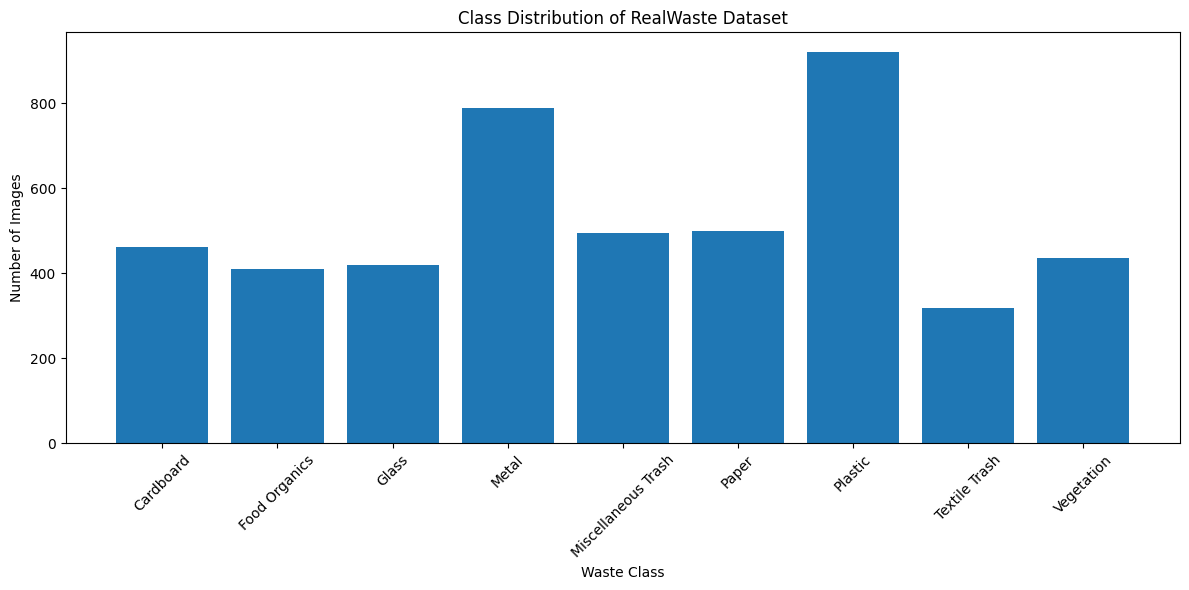

In [9]:
plt.figure(figsize=(12, 6))

plt.bar(
    count_df["Class"],
    count_df["Number of Images"]
)

plt.title("Class Distribution of RealWaste Dataset")
plt.xlabel("Waste Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [10]:
data = []

for class_name in classes:
    class_folder = os.path.join(DATASET_PATH, class_name)

    for filename in os.listdir(class_folder):

        if filename.lower().endswith((".jpg", ".jpeg", ".png")):

            relative_path = os.path.join(
                class_name,
                filename
            )

            data.append({
                "relative_path": relative_path,
                "label": class_name
            })

df = pd.DataFrame(data)

print("Total number of images:", len(df))

df.head()

Total number of images: 4752


,relative_path,label
0,Cardboard/Cardboard_454.jpg,Cardboard
1,Cardboard/Cardboard_430.jpg,Cardboard
2,Cardboard/Cardboard_254.jpg,Cardboard
3,Cardboard/Cardboard_278.jpg,Cardboard
4,Cardboard/Cardboard_327.jpg,Cardboard


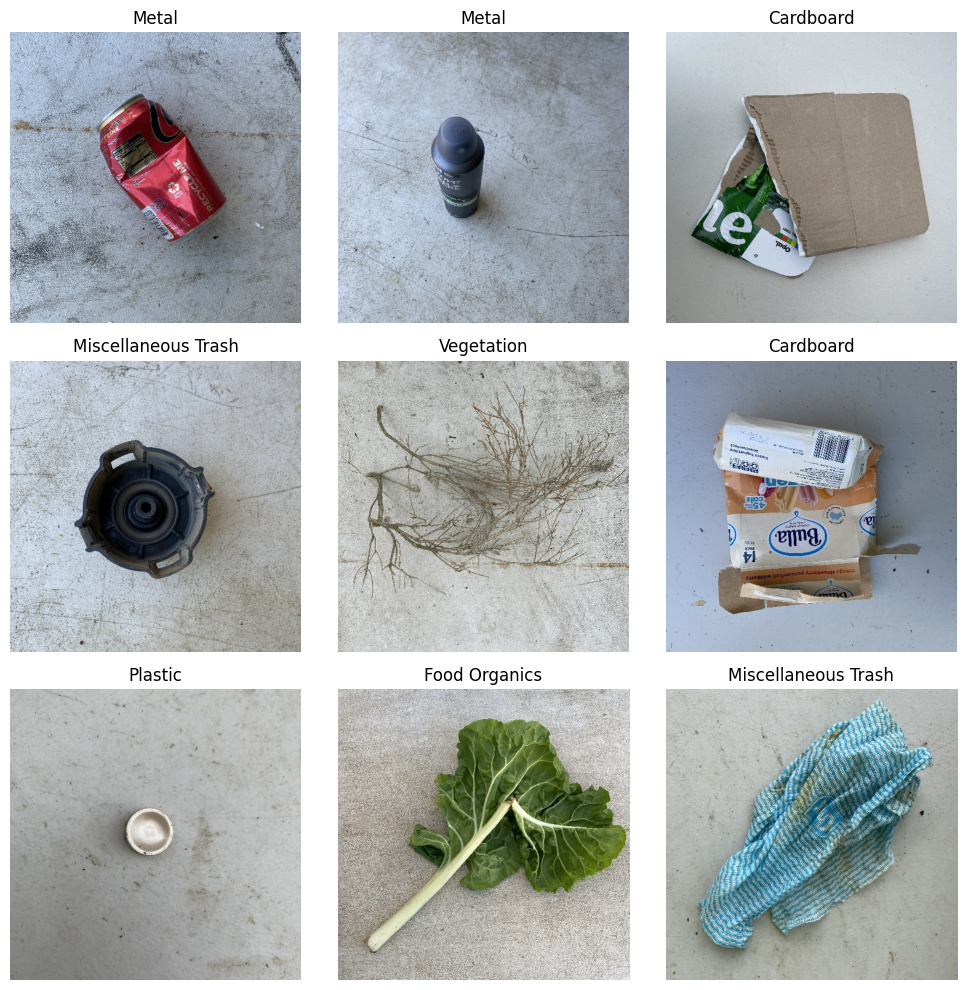

In [11]:
sample_df = df.sample(9, random_state=SEED)

plt.figure(figsize=(10, 10))

for i, (_, row) in enumerate(sample_df.iterrows()):

    image_path = os.path.join(
        DATASET_PATH,
        row["relative_path"]
    )

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

In [14]:
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

In [15]:
print("Total:", len(df))
print("Training:", len(train_df))
print("Validation:", len(validation_df))
print("Testing:", len(test_df))

Total: 4752
Training: 3326
Validation: 713
Testing: 713


In [16]:
print(
    "Training:",
    round(len(train_df) / len(df) * 100, 2),
    "%"
)

print(
    "Validation:",
    round(len(validation_df) / len(df) * 100, 2),
    "%"
)

print(
    "Testing:",
    round(len(test_df) / len(df) * 100, 2),
    "%"
)

Training: 69.99 %
Validation: 15.0 %
Testing: 15.0 %


In [17]:
print("TRAINING DATA")
print(train_df["label"].value_counts())

print("\nVALIDATION DATA")
print(validation_df["label"].value_counts())

print("\nTEST DATA")
print(test_df["label"].value_counts())

TRAINING DATA
label
Plastic                645
Metal                  553
Paper                  350
Miscellaneous Trash    346
Cardboard              323
Vegetation             305
Glass                  294
Food Organics          288
Textile Trash          222
Name: count, dtype: int64

VALIDATION DATA
label
Plastic                138
Metal                  119
Paper                   75
Miscellaneous Trash     74
Cardboard               69
Vegetation              66
Glass                   63
Food Organics           61
Textile Trash           48
Name: count, dtype: int64

TEST DATA
label
Plastic                138
Metal                  118
Miscellaneous Trash     75
Paper                   75
Cardboard               69
Vegetation              65
Glass                   63
Food Organics           62
Textile Trash           48
Name: count, dtype: int64


In [18]:
os.makedirs("/content/splits", exist_ok=True)

In [19]:
train_df.to_csv(
    "/content/splits/train.csv",
    index=False
)

validation_df.to_csv(
    "/content/splits/validation.csv",
    index=False
)

test_df.to_csv(
    "/content/splits/test.csv",
    index=False
)

print("Split files saved successfully!")

Split files saved successfully!


In [20]:
!ls -lh /content/splits

total 180K
-rw-r--r-- 1 root root  27K Sep 18 15:28 test.csv
-rw-r--r-- 1 root root 122K Sep 18 15:28 train.csv
-rw-r--r-- 1 root root  27K Sep 18 15:28 validation.csv


In [21]:
from google.colab import files

files.download("/content/splits/train.csv")
files.download("/content/splits/validation.csv")
files.download("/content/splits/test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>